**生成式 AI 使用说明**：在本课程作业中，使用生成式 AI 需要遵守与协作讨论相同的政策。和其他合作者一样，每位学生都必须独立写出自己的解答，不能直接依赖交互输出完成提交内容，并且提交时应说明协作的性质。使用生成式 AI 工具实质性地完成作业中的部分内容，不符合本课程作业精神，也会违反 [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

# 图像特征练习
*请完成并提交这份 worksheet，包括运行输出，以及 worksheet 之外你修改过的所有辅助代码。更多细节请参考课程网站上的 [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html)。*

我们已经看到，在输入图像的原始像素上训练线性分类器，可以在图像分类任务中取得还算不错的效果。在本练习中，我们会展示：不直接使用原始像素，而是在由原始像素计算得到的特征上训练线性分类器，可以进一步提升分类性能。

本练习的所有工作都将在这个 notebook 中完成。

In [1]:
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## 加载数据
与前面的练习类似，我们将从磁盘加载 CIFAR-10 数据。

In [2]:
from cs231n.features import color_histogram_hsv, hog_feature

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

    # Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
    try:
       del X_train, y_train
       del X_test, y_test
       print('Clear previously loaded data.')
    except:
       pass

    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # Subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

## 提取特征
对于每张图像，我们会计算方向梯度直方图（Histogram of Oriented Gradients，HOG），同时使用 HSV 色彩空间中的色相（Hue）通道计算颜色直方图。最后，将 HOG 特征向量与颜色直方图特征向量拼接起来，形成每张图像的最终特征向量。

粗略来说，HOG 应该能够捕捉图像的纹理，同时忽略颜色信息；颜色直方图则表示输入图像的颜色，同时忽略纹理。因此，我们预计二者结合使用会比单独使用其中任何一种效果更好。如果你感兴趣，可以自行验证这一假设。

`hog_feature` 和 `color_histogram_hsv` 函数都以单张图像为输入，并返回该图像的特征向量。`extract_features` 函数接收一组图像和一个特征函数列表，在每张图像上计算每个特征函数，并把结果存入矩阵；矩阵中的每一列都是对应图像的所有特征向量拼接后的结果。

In [3]:
from cs231n.features import *

# num_color_bins = 10 # Number of bins in the color histogram
num_color_bins = 25 # Number of bins in the color histogram
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats = extract_features(X_val, feature_fns)
X_test_feats = extract_features(X_test, feature_fns)

# Preprocessing: Subtract the mean feature
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_val_feats -= mean_feat
X_test_feats -= mean_feat

# Preprocessing: Divide by standard deviation. This ensures that each feature
# has roughly the same scale.
std_feat = np.std(X_train_feats, axis=0, keepdims=True)
X_train_feats /= std_feat
X_val_feats /= std_feat
X_test_feats /= std_feat

# Preprocessing: Add a bias dimension
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_val_feats = np.hstack([X_val_feats, np.ones((X_val_feats.shape[0], 1))])
X_test_feats = np.hstack([X_test_feats, np.ones((X_test_feats.shape[0], 1))])

Done extracting features for 1000 / 49000 images
Done extracting features for 2000 / 49000 images
Done extracting features for 3000 / 49000 images
Done extracting features for 4000 / 49000 images
Done extracting features for 5000 / 49000 images
Done extracting features for 6000 / 49000 images
Done extracting features for 7000 / 49000 images
Done extracting features for 8000 / 49000 images
Done extracting features for 9000 / 49000 images
Done extracting features for 10000 / 49000 images
Done extracting features for 11000 / 49000 images
Done extracting features for 12000 / 49000 images
Done extracting features for 13000 / 49000 images
Done extracting features for 14000 / 49000 images
Done extracting features for 15000 / 49000 images
Done extracting features for 16000 / 49000 images
Done extracting features for 17000 / 49000 images
Done extracting features for 18000 / 49000 images
Done extracting features for 19000 / 49000 images
Done extracting features for 20000 / 49000 images
Done extr

## 在特征上训练 Softmax 分类器
使用本次作业前面实现的 Softmax 代码，在上面提取的特征上训练 Softmax 分类器；其效果应该优于直接在原始像素上训练。

In [18]:
# Use the validation set to tune the learning rate and regularization strength

from cs231n.classifiers.linear_classifier import Softmax

learning_rates = [1e-7, 1e-6,1e-5,1e-4]
regularization_strengths = [5e4,5e5, 5e6,5e7]

results = {}
best_val = -1
best_softmax = None

################################################################################
# TODO:                                                                        #
# Use the validation set to set the learning rate and regularization strength. #
# This should be identical to the validation that you did for the Softmax; save#
# the best trained classifer in best_softmax. If you carefully tune the model, #
# you should be able to get accuracy of above 0.42 on the validation set.      #
################################################################################
for lr in learning_rates:
    for reg in regularization_strengths:
        softmax=Softmax()
        softmax.train(X_train_feats,y_train,learning_rate=lr,reg=reg)
        y_train_pred=softmax.predict(X_train_feats)
        y_val_pred=softmax.predict(X_val_feats)
        train_accuracy=np.mean(y_train_pred==y_train)
        val_accuracy=np.mean(y_val_pred==y_val)

        results[(lr, reg)]=(train_accuracy,val_accuracy)
        if val_accuracy>best_val:
            best_val=val_accuracy
            best_softmax=softmax

# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved: %f' % best_val)

c:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment1\cs231n\classifiers\softmax.py:80: RuntimeWarning: divide by zero encountered in log
  loss =-np.mean(np.log(correct))
c:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment1\cs231n\classifiers\softmax.py:81: RuntimeWarning: overflow encountered in scalar multiply
  loss +=reg*np.sum(W**2)
c:\Users\lenovo\Desktop\cs by orbro\cs231n\.venv312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment1\cs231n\classifiers\softmax.py:81: RuntimeWarning: overflow encountered in square
  loss +=reg*np.sum(W**2)


lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.087327 val accuracy: 0.073000
lr 1.000000e-07 reg 5.000000e+05 train accuracy: 0.343143 val accuracy: 0.340000
lr 1.000000e-07 reg 5.000000e+06 train accuracy: 0.345388 val accuracy: 0.355000
lr 1.000000e-07 reg 5.000000e+07 train accuracy: 0.100367 val accuracy: 0.098000
lr 1.000000e-06 reg 5.000000e+04 train accuracy: 0.413204 val accuracy: 0.410000
lr 1.000000e-06 reg 5.000000e+05 train accuracy: 0.328551 val accuracy: 0.351000
lr 1.000000e-06 reg 5.000000e+06 train accuracy: 0.095571 val accuracy: 0.109000
lr 1.000000e-06 reg 5.000000e+07 train accuracy: 0.104714 val accuracy: 0.109000
lr 1.000000e-05 reg 5.000000e+04 train accuracy: 0.324878 val accuracy: 0.354000
lr 1.000000e-05 reg 5.000000e+05 train accuracy: 0.094224 val accuracy: 0.096000
lr 1.000000e-05 reg 5.000000e+06 train accuracy: 0.112102 val accuracy: 0.124000
lr 1.000000e-05 reg 5.000000e+07 train accuracy: 0.098592 val accuracy: 0.104000
lr 1.000000e-04 reg 5.000000

c:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment1\cs231n\classifiers\softmax.py:91: RuntimeWarning: overflow encountered in multiply
  dW=X.T@dscores/X.shape[0]+2*reg*W
c:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment1\cs231n\classifiers\softmax.py:76: RuntimeWarning: invalid value encountered in matmul
  scores=X@W


In [19]:
# Evaluate your trained Softmax on the test set: you should be able to get at least 0.42
y_test_pred = best_softmax.predict(X_test_feats)
test_accuracy = np.mean(y_test == y_test_pred)
print(test_accuracy)

0.42


In [20]:
# Save best softmax model
best_softmax.save("best_softmax_features.npy")

best_softmax_features.npy saved.


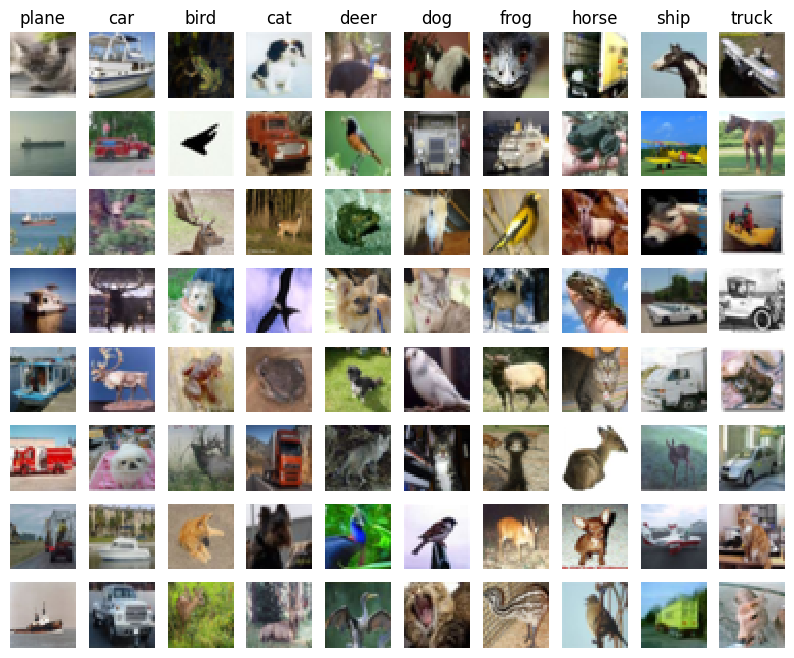

In [21]:
# An important way to gain intuition about how an algorithm works is to
# visualize the mistakes that it makes. In this visualization, we show examples
# of images that are misclassified by our current system. The first column
# shows images that our system labeled as "plane" but whose true label is
# something other than "plane".

examples_per_class = 8
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for cls, cls_name in enumerate(classes):
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    idxs = np.random.choice(idxs, examples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(examples_per_class, len(classes), i * len(classes) + cls + 1)
        plt.imshow(X_test[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls_name)
plt.show()

### 行内问题 1：
描述你看到的误分类结果。它们是否符合直觉？


$\color{blue}{\textit{你的答案：}}$





## 在图像特征上训练神经网络
在本次作业前面的内容中，我们看到：在原始像素上训练两层神经网络，其分类性能优于在原始像素上训练线性分类器。在这个 notebook 中，我们又看到：在图像特征上训练线性分类器，效果优于在原始像素上训练线性分类器。

为了完整起见，我们还应该尝试在图像特征上训练神经网络。这种方法应当优于前面的所有方法：你应该可以轻松在测试集上达到 55% 以上的分类准确率；我们的最佳模型达到了约 60% 的分类准确率。

In [14]:
# Preprocessing: Remove the bias dimension
# Make sure to run this cell only ONCE
print(X_train_feats.shape)
X_train_feats = X_train_feats[:, :-1]
X_val_feats = X_val_feats[:, :-1]
X_test_feats = X_test_feats[:, :-1]

print(X_train_feats.shape)

(49000, 170)
(49000, 169)


In [24]:
from cs231n.classifiers.fc_net import TwoLayerNet
from cs231n.solver import Solver

input_dim = X_train_feats.shape[1]
hidden_dim = 500
num_classes = 10

data = {
    'X_train': X_train_feats,
    'y_train': y_train,
    'X_val': X_val_feats,
    'y_val': y_val,
    'X_test': X_test_feats,
    'y_test': y_test,
}
nn_learning_rates = [1e-2, 5e-2, 1e-1]
nn_regularization_strengths = [1e-4, 1e-3, 1e-2]
num_epochs_list = [5, 10, 15]
best_net = None
Greatest = [0, 0, 0, 0]
best_solver = None
################################################################################
# TODO: Train a two-layer neural network on image features. You may want to    #
# cross-validate various parameters as in previous sections. Store your best   #
# model in the best_net variable.                                              #
################################################################################
for lr in nn_learning_rates:
    for ne in num_epochs_list:
        for reg in nn_regularization_strengths:
            net = TwoLayerNet(input_dim, hidden_dim, num_classes, reg=reg)
            solver = Solver(
                net,
                data,
                update_rule="sgd",
                optim_config={"learning_rate": lr},
                lr_decay=0.95,
                num_epochs=ne,
                batch_size=200,
                print_every=100,
                verbose=False,
            )
            solver.train()
            current_val = solver.best_val_acc
            print(f"lr={lr}, num_epochs={ne}, reg={reg}, val_acc={current_val}")
            if current_val > Greatest[0]:
                Greatest[0] = current_val
                Greatest[1] = lr
                Greatest[2] = ne
                Greatest[3] = reg
                best_net = net
                best_solver = solver
print(f"The best val_accuracy is {Greatest[0]}, its learning_rate is {Greatest[1]}, the num_epochs is {Greatest[2]}, the reg is {Greatest[3]}")
        


lr=0.01, num_epochs=5, reg=0.0001, val_acc=0.287
lr=0.01, num_epochs=5, reg=0.001, val_acc=0.299
lr=0.01, num_epochs=5, reg=0.01, val_acc=0.292
lr=0.01, num_epochs=10, reg=0.0001, val_acc=0.377
lr=0.01, num_epochs=10, reg=0.001, val_acc=0.372
lr=0.01, num_epochs=10, reg=0.01, val_acc=0.362
lr=0.01, num_epochs=15, reg=0.0001, val_acc=0.422
lr=0.01, num_epochs=15, reg=0.001, val_acc=0.426
lr=0.01, num_epochs=15, reg=0.01, val_acc=0.419
lr=0.05, num_epochs=5, reg=0.0001, val_acc=0.516
lr=0.05, num_epochs=5, reg=0.001, val_acc=0.518
lr=0.05, num_epochs=5, reg=0.01, val_acc=0.515
lr=0.05, num_epochs=10, reg=0.0001, val_acc=0.537
lr=0.05, num_epochs=10, reg=0.001, val_acc=0.528
lr=0.05, num_epochs=10, reg=0.01, val_acc=0.526
lr=0.05, num_epochs=15, reg=0.0001, val_acc=0.553
lr=0.05, num_epochs=15, reg=0.001, val_acc=0.551
lr=0.05, num_epochs=15, reg=0.01, val_acc=0.53
lr=0.1, num_epochs=5, reg=0.0001, val_acc=0.544
lr=0.1, num_epochs=5, reg=0.001, val_acc=0.537
lr=0.1, num_epochs=5, reg=0.01

In [25]:
# Run your best neural net classifier on the test set. You should be able
# to get more than 58% accuracy. It is also possible to get >60% accuracy
# with careful tuning.

y_test_pred = np.argmax(best_net.loss(data['X_test']), axis=1)
test_acc = (y_test_pred == data['y_test']).mean()
print(test_acc)

0.577


In [26]:
# Save best model
best_net.save("best_two_layer_net_features.npy")

best_two_layer_net_features.npy saved.
